In [1]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import sys
import dask.dataframe as dd
import dask.array as da
from icecube import icetray, dataio, phys_services                                                                        
from icecube import dataclasses  
from matplotlib.colors import LogNorm
from scipy.stats import ks_2samp
import tables

sys.path.insert(0, "/data/user/akatil/electron_neutrino/for_real/analysis_chain/")

from analysis_helpers import get_mean_upgrade_positions

In [2]:
#getting the geometry frame. We want this to calculate the mean of upgrade om x and y positions
gcd_infile = dataio.I3File('/home/akatil/GeoCalibDetectorStatus_ICUpgrade.v58.mixed.V1.i3.bz2')

f_geo = gcd_infile
geo_frame = f_geo.pop_frame(icetray.I3Frame.Geometry)
geo = geo_frame['I3Geometry']

ux, uy, uz = get_mean_upgrade_positions(geo)

fCC = tables.open_file('../../../dataset_complete/merger/merged_CC.h5', mode='r')
fNC = tables.open_file('../../../dataset_complete/merger/merged_NC.h5', mode='r')

In [3]:
emin, emax = 0, 100

imin, imax = 0, 0.1

#interaction_type = 0

#f = fCC

def get_boolean(f, interaction_type):
    event_counter = f.root.EventCounter.col("value")
    print(event_counter)
    print('started counter')
    
    energy = f.root.PrimaryEnergy.col("value")
    inelasticity = f.root.Inelasticity.col("value")
    
    trueX = f.root.TrueX.col("value")
    trueY = f.root.TrueY.col("value")
    trueZ = f.root.TrueZ.col("value")
    
    energy_boolean = (energy >= emin) & (energy <= emax)
    inelasticity_boolean = (inelasticity >= imin) & (inelasticity <= imax)
    vertex_boolean = (trueZ <= uz+150)&(trueZ >= uz-150)&(trueX <= ux+50)&(trueX >= ux-50)&(trueY <= uy+40)&(trueY >= uy-40)
    print('defined booleans')
    
    if interaction_type == 0:
        event_boolean = energy_boolean & inelasticity_boolean & vertex_boolean
    if interaction_type == 1:
        event_boolean = energy_boolean & vertex_boolean

    return event_boolean

In [4]:
event_booleanCC = get_boolean(fCC, 0)
event_booleanNC = get_boolean(fNC, 1)

[1.00000737e+10 1.00000737e+10 1.00000737e+10 ... 1.00025629e+10
 1.00025629e+10 1.00025629e+10]
started counter
defined booleans
[2.00000000e+10 2.00000000e+10 2.00000000e+10 ... 2.00022403e+10
 2.00022403e+10 2.00022403e+10]
started counter
defined booleans


In [5]:
def reco_vs_true(trueCC, recoCC, xlabelCC, ylabelCC, 
                 trueNC, recoNC, xlabelNC, ylabelNC):
    
    fig, axs = plt.subplots(1, 2)
    fig.set_figheight(8)
    fig.set_figwidth(20)
    
    a0 = axs[0].hist2d(trueCC, recoCC, cmap='jet', norm=LogNorm(), density=False, bins=100)
    fig.colorbar(a0[3], ax=axs[0])
    axs[0].set_xlabel(xlabelCC, fontsize = 18)
    axs[0].set_ylabel(ylabelCC, fontsize = 18)
    axs[0].set_title('CC - Energy {} - {} GeV'.format(emin, emax))
    
    lims = [
        np.min([axs[0].get_xlim(), axs[0].get_ylim()]),
        np.max([axs[0].get_xlim(), axs[0].get_ylim()]),
    ]
    
    axs[0].plot(lims, lims, 'k-', lw=3)
    
    
    a1 = axs[1].hist2d(trueNC, recoNC, cmap='jet', norm=LogNorm(), density=False, bins=100)
    fig.colorbar(a1[3], ax=axs[1])
    axs[1].set_xlabel(xlabelNC, fontsize = 18)
    axs[1].set_ylabel(ylabelNC, fontsize = 18)
    axs[1].set_title('NC - Energy {} - {} GeV'.format(emin, emax))
    
    lims = [
        np.min([axs[1].get_xlim(), axs[1].get_ylim()]),
        np.max([axs[1].get_xlim(), axs[1].get_ylim()]),
    ]
    
    axs[1].plot(lims, lims, 'k-', lw=3)
    
    plt.show()

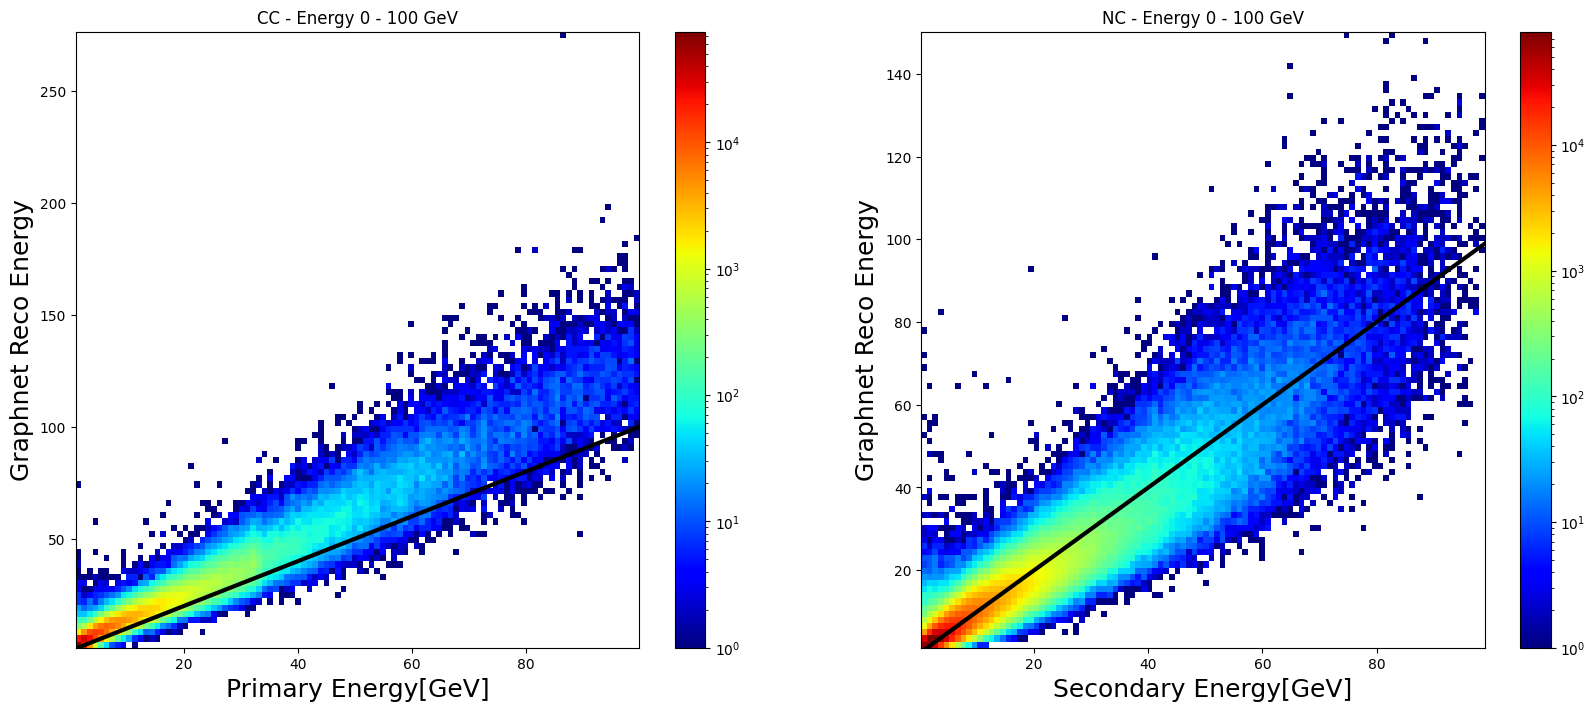

In [6]:
reco_vs_true(fCC.root.PrimaryEnergy.col('value')[event_booleanCC], fCC.root.RecoEnergy.col('value')[event_booleanCC], 'Primary Energy[GeV]', 'Graphnet Reco Energy',
            fNC.root.SecondaryEnergy.col('value')[event_booleanNC], fNC.root.RecoEnergy.col('value')[event_booleanNC], 'Secondary Energy[GeV]', 'Graphnet Reco Energy')

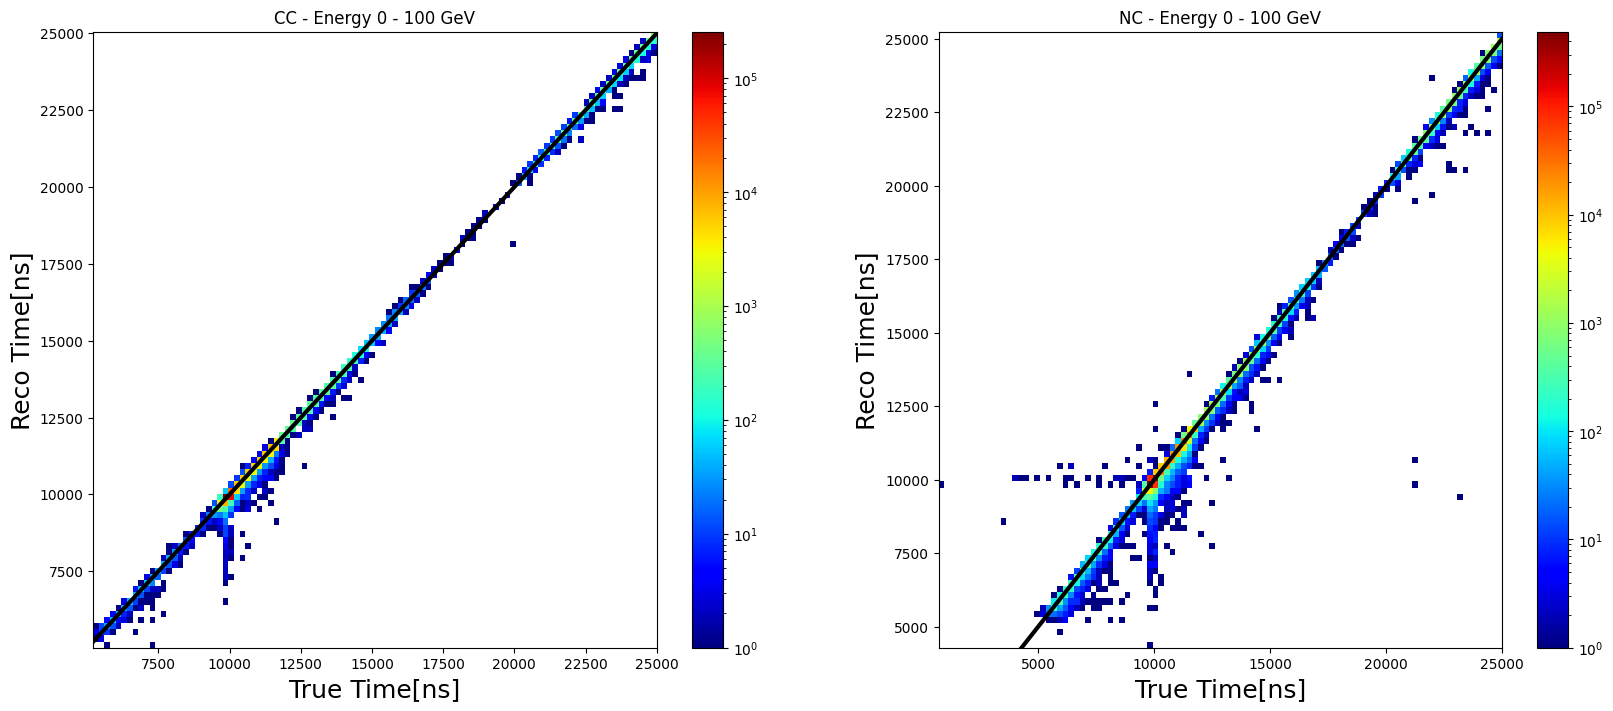

In [9]:
reco_vs_true(fCC.root.TrueTime.col('value')[event_booleanCC], fCC.root.RecoVertexTime.col('value')[event_booleanCC], 'True Time[ns]', 'Reco Time[ns]',
            fNC.root.TrueTime.col('value')[event_booleanNC], fNC.root.RecoVertexTime.col('value')[event_booleanNC],  'True Time[ns]', 'Reco Time[ns]',)

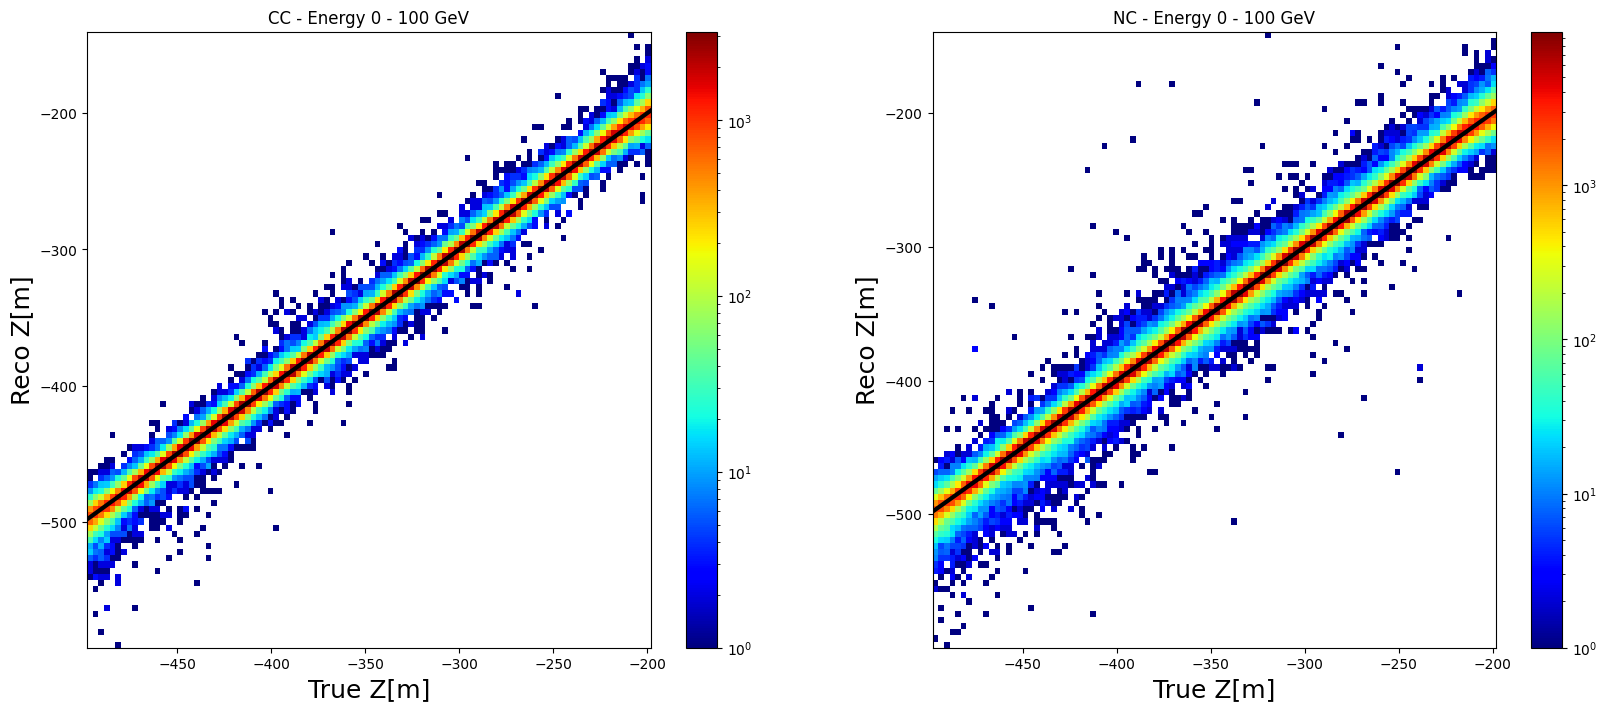

In [8]:
reco_vs_true(fCC.root.TrueZ.col('value')[event_booleanCC], fCC.root.RecoZ.col('value')[event_booleanCC], 'True Z[m]', 'Reco Z[m]',
            fNC.root.TrueZ.col('value')[event_booleanNC], fNC.root.RecoZ.col('value')[event_booleanNC], 'True Z[m]', 'Reco Z[m]',)

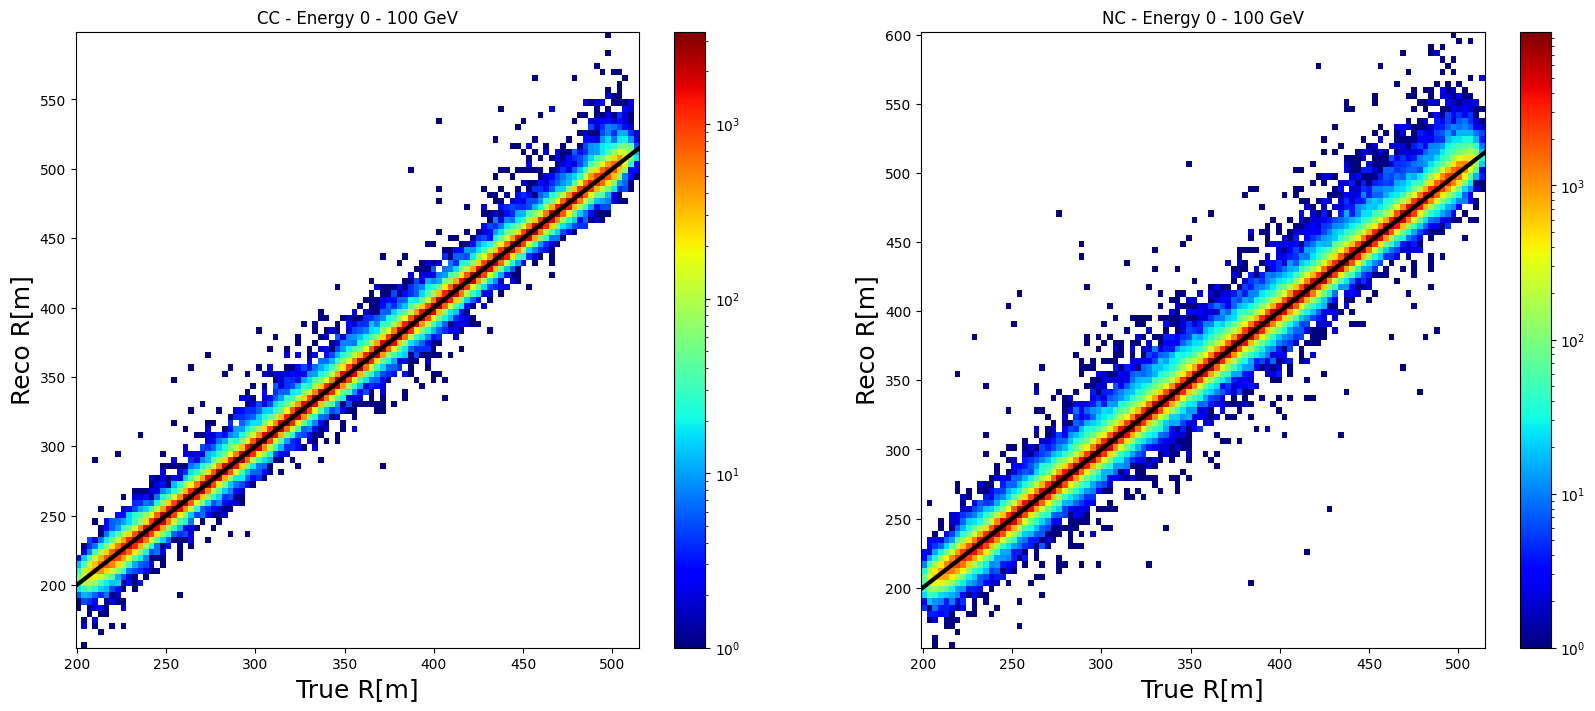

In [10]:
# reco vs true R

true_RCC = np.sqrt(fCC.root.TrueX.col('value')[event_booleanCC]**2+ fCC.root.TrueY.col('value')[event_booleanCC]**2+ fCC.root.TrueZ.col('value')[event_booleanCC]**2)
reco_RCC = np.sqrt(fCC.root.RecoX.col('value')[event_booleanCC]**2+ fCC.root.RecoY.col('value')[event_booleanCC]**2+ fCC.root.RecoZ.col('value')[event_booleanCC]**2)

true_RNC = np.sqrt(fNC.root.TrueX.col('value')[event_booleanNC]**2+fNC.root.TrueY.col('value')[event_booleanNC]**2+fNC.root.TrueZ.col('value')[event_booleanNC]**2)
reco_RNC = np.sqrt(fNC.root.RecoX.col('value')[event_booleanNC]**2+fNC.root.RecoY.col('value')[event_booleanNC]**2+fNC.root.RecoZ.col('value')[event_booleanNC]**2)

reco_vs_true(true_RCC, reco_RCC, 'True R[m]', 'Reco R[m]',
            true_RNC, reco_RNC, 'True R[m]', 'Reco R[m]',)

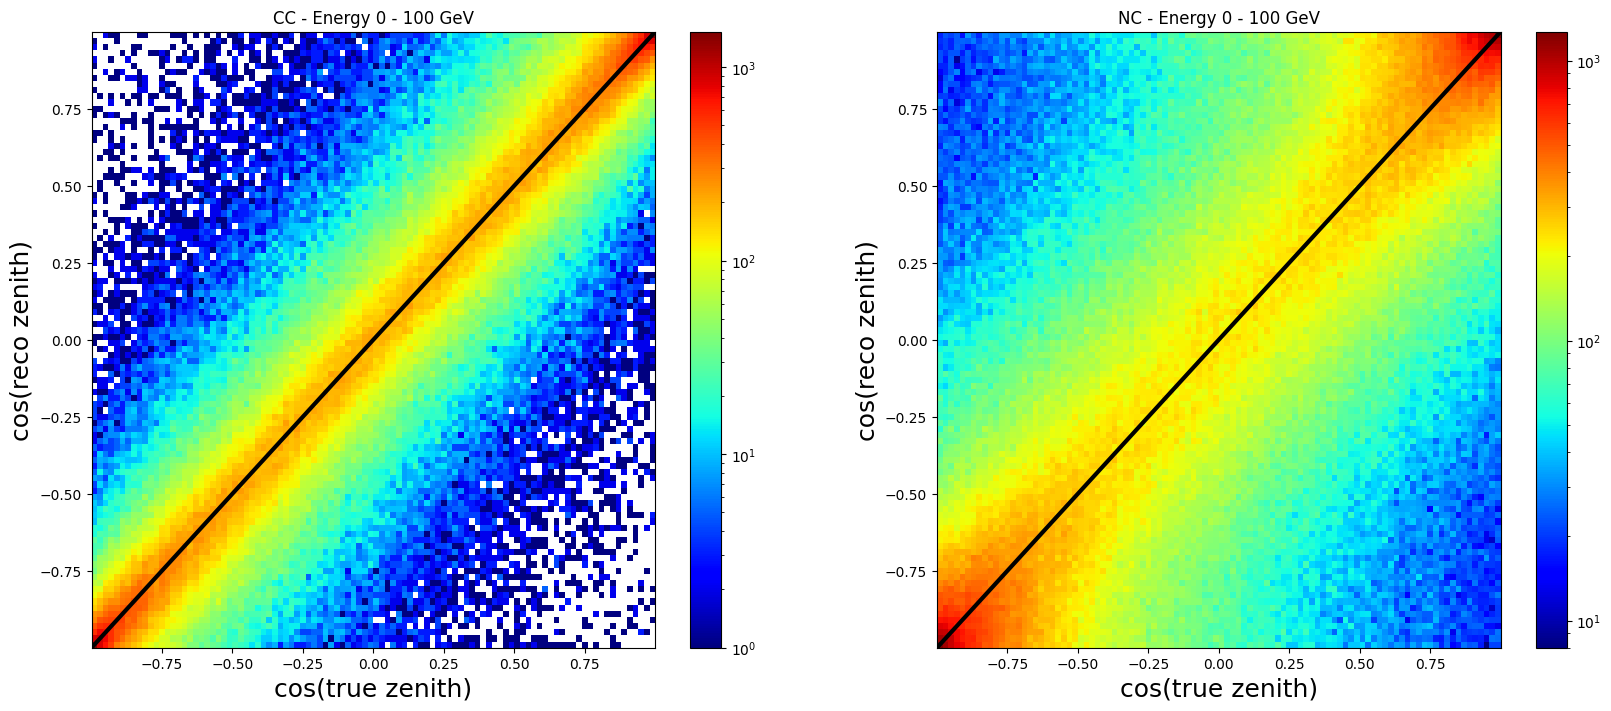

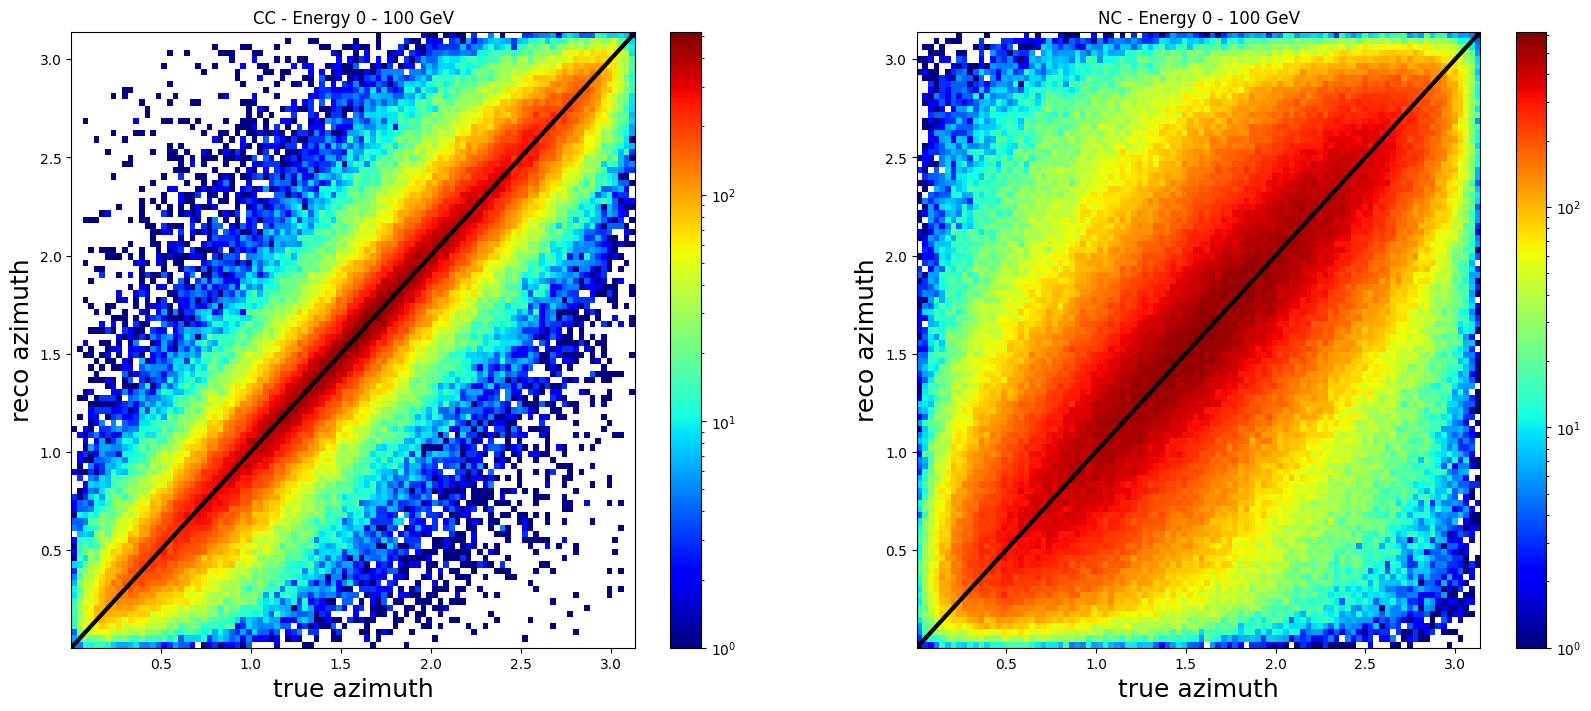

In [11]:
# azimuth and zenith

def calculate_zenith_azimuth(x, y, z):

    r = np.sqrt((x)**2 + (y)**2 + (z)**2)
    theta = np.arccos(z/r)
    phi = np.arctan2(y, x)

    return theta, phi
    
    #az = np.nan_to_num(np.arctan2(y, x))
                            
    #if az < 0:
        #az = az + 2*np.pi

true_zenithCC, true_azimuthCC = fCC.root.Zenith.col('value')[event_booleanCC], fCC.root.Azimuth.col('value')[event_booleanCC]
reco_zenithCC, reco_azimuthCC = calculate_zenith_azimuth(fCC.root.RecoDirX.col('value')[event_booleanCC], fCC.root.RecoDirY.col('value')[event_booleanCC], fCC.root.RecoDirZ.col('value')[event_booleanCC])

true_zenithNC, true_azimuthNC = fNC.root.Zenith.col('value')[event_booleanNC], fNC.root.Azimuth.col('value')[event_booleanNC]
reco_zenithNC, reco_azimuthNC = calculate_zenith_azimuth(fNC.root.RecoDirX.col('value')[event_booleanNC], fNC.root.RecoDirY.col('value')[event_booleanNC], fNC.root.RecoDirZ.col('value')[event_booleanNC])

reco_vs_true(np.cos(true_zenithCC), np.cos(reco_zenithCC), 'cos(true zenith)', 'cos(reco zenith)',
            np.cos(true_zenithNC), np.cos(reco_zenithNC), 'cos(true zenith)', 'cos(reco zenith)',)

reco_vs_true(true_zenithCC, reco_zenithCC, 'true azimuth', 'reco azimuth',
            true_zenithNC, reco_zenithNC, 'true azimuth', 'reco azimuth',)